<div >
<img src = "figs/ans_banner_1920x200.png" />
</div>

# Caso-taller: Identificando  Burger Master con MMG

El Burger Master es un evento creado en el 2016 por el *influencer* Tulio Zuluaga, más conocido en redes como Tulio recomienda, el cual busca que por una semana las hamburgueserías de cada ciudad ofrezcan su mejor producto a un precio reducido. 

El evento ha venido creciendo y en el 2022 se extendió por 21 ciudades de Colombia para las cuales se estimó que se vendieron más de dos millones de hamburguesas. El objetivo del presente caso-taller  es identificar los puntos calientes de hamburgueserías  que compitieron en  la ciudad de Bogotá aplicando el Modelo de Mezclas Gaussianas.

## Instrucciones generales

1. Para desarrollar el *cuaderno* primero debe descargarlo.

2. Para responder cada inciso deberá utilizar el espacio debidamente especificado.

3. La actividad será calificada sólo si sube el *cuaderno* de jupyter notebook con extensión `.ipynb` en la actividad designada como "Revisión por el compañero."

4. El archivo entregado debe poder ser ejecutado localmente por los pares. Sea cuidadoso con la especificación de la ubicación de los archivos de soporte, guarde la carpeta de datos  en la misma ruta de acceso del cuaderno, por ejemplo: `data`.


## Desarrollo

#### Config

In [108]:
from __future__ import annotations

%load_ext autoreload
%autoreload 2

# python
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm # Para las paletas de colores
from matplotlib.colors import to_rgba
from matplotlib.patches import Ellipse
import session_info

# tools
import re
import json
from pathlib import Path
from inspect import cleandoc
from dataclasses import dataclass
from unidecode import unidecode
from enum import Enum

# stats
import statsmodels.api as sm
from scipy import stats
from statsmodels.nonparametric.kernel_density import KDEMultivariate


# Geo
import folium
import geojsoncontour
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon
from shapely.ops import unary_union
from pyrosm import OSM, get_data
from geopy.distance import geodesic


# sklearn
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV


# typings
from typing import List, Tuple, Dict, Any, Union, Optional

# Omitir advertencias
import warnings
warnings.filterwarnings("ignore")

# setup
plt.style.use('seaborn')
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('max_colwidth', None)

# decimals
np.set_printoptions(precision=6)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


##### Información de Sesión

In [18]:
session_info.show(html=False)

-----
folium              0.14.0
geojsoncontour      NA
geopandas           0.10.2
geopy               2.4.0
matplotlib          3.3.1
numpy               1.19.1
pandas              1.1.1
pyrosm              NA
scipy               1.7.3
seaborn             0.12.2
session_info        1.0.0
shapely             1.8.5
sklearn             0.23.2
statsmodels         0.13.5
unidecode           NA
-----
IPython             7.34.0
jupyter_client      7.4.9
jupyter_core        4.12.0
jupyterlab          2.1.1
notebook            6.0.3
-----
Python 3.7.17 (default, Jun 13 2023, 16:36:15) [GCC 8.3.0]
Linux-5.15.49-linuxkit-x86_64-with-debian-10.13
-----
Session information updated at 2025-09-29 01:24


### utils

In [19]:
# utils
# rutas absolutas: agnostico al sistema operativo
here: Path = Path.cwd().absolute()
data: Path = here / 'data'

burger_master_xlsx: Path = data / 'burger_master.xlsx'

### 1. Carga de datos  

En la carpeta `data` se encuentra el archivo `burger_master.xlsx` para la ciudad de Bogotá, cargue estos datos en su *cuaderno* y reporte brevemente el contenido de la base.

In [20]:
# Utilice este espacio para escribir el código.
def clean_colname(name: str) -> str:
    """Limpia el nombre de una cadena de texto.
        esto con la finalidad de llamar luego
        los campos del DataFrame de forma más sencilla.
        a traves de punto como si fueran atributos 
        del DataFrame.

    Args:
        name (str): Nombre a limpiar.

    Returns:
        str: Nombre limpio.
    """
    name = name.strip()  # Elimina espacios en blanco al inicio y al final
    name = unidecode(name)  # Elimina tildes y caracteres especiales
    name = name.lower()  # Convierte a minúsculas
    name = name.replace(' ', '_')  # Reemplaza espacios por guiones bajos
    name = re.sub(r'[^\x00-\x7F]+', '', name)
    return name

bogota_mb_df = pd.read_excel(
    burger_master_xlsx, engine='openpyxl'
).rename(columns=clean_colname)

bogota_mb_df = gpd.GeoDataFrame(
    bogota_mb_df, geometry = gpd.points_from_xy(bogota_mb_df.latitud, bogota_mb_df.longitud)
)
bogota_mb_df.crs = "EPSG:4326" #la proyección WGS84, ya que tenemos la latitudes y longitudes que los ubican en el mapa,
                               #pero luego lo proyectamos a MAGNA-SIRGAS para tener la proyección que corresponde a Bogotá.

print("Dimensiones:", bogota_mb_df.shape)
print("Franquicia de Restaurantes:", bogota_mb_df.restaurante.unique().shape[0], "\n")
print(bogota_mb_df.info())
bogota_mb_df.head(3)

Dimensiones: (137, 6)
Franquicia de Restaurantes: 63 

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   restaurante  137 non-null    object  
 1   direccion    137 non-null    object  
 2   descripcion  137 non-null    object  
 3   latitud      137 non-null    float64 
 4   longitud     137 non-null    float64 
 5   geometry     137 non-null    geometry
dtypes: float64(2), geometry(1), object(3)
memory usage: 6.5+ KB
None


,restaurante,direccion,descripcion,latitud,longitud,geometry
0,MAIKKI,Cra 75 # 24D – 48,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado, tocineta caramelizada en melao de maracuyá y panela de la hoya del rio Suárez, carne de res del Magdalena medio, queso fresco de pasta hilada, mayonesa de cilantro cimarrón del pacifico, cogollo de lechuga y pan artesanal. Un homenaje a lo nuestro. En pie de lucha por la comida rápida colombiana<br/><br/>Cra 75 # 24D – 48, Modelia<br/>Calle 119 # 11A – 24, Santa Bárbara<br/>Cra 47A # 98 – 47, Castellana</p>",4.668833,-74.116828,POINT (4.66883 -74.11683)
1,MAIKKI,Calle 119 # 11A – 24,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado, tocineta caramelizada en melao de maracuyá y panela de la hoya del rio Suárez, carne de res del Magdalena medio, queso fresco de pasta hilada, mayonesa de cilantro cimarrón del pacifico, cogollo de lechuga y pan artesanal. Un homenaje a lo nuestro. En pie de lucha por la comida rápida colombiana<br/><br/>Cra 75 # 24D – 48, Modelia<br/>Calle 119 # 11A – 24, Santa Bárbara<br/>Cra 47A # 98 – 47, Castellana</p>",4.698395,-74.036585,POINT (4.69839 -74.03658)
2,MAIKKI,Cra 47A # 98 – 47,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado, tocineta caramelizada en melao de maracuyá y panela de la hoya del rio Suárez, carne de res del Magdalena medio, queso fresco de pasta hilada, mayonesa de cilantro cimarrón del pacifico, cogollo de lechuga y pan artesanal. Un homenaje a lo nuestro. En pie de lucha por la comida rápida colombiana<br/><br/>Cra 75 # 24D – 48, Modelia<br/>Calle 119 # 11A – 24, Santa Bárbara<br/>Cra 47A # 98 – 47, Castellana</p>",4.686401,-74.060144,POINT (4.68640 -74.06014)


(Utilice este espacio para describir el procedimiento, análisis, y conclusiones)

Datos que corresponden a la ciudad de Bogotá D.C.

* Registros : 137
* Franquicias de Restaurantes: 63
* Información sobre hamburguesas que se ofrecen en cada restaurante.

| Campo | Tipo de dato | Descripción  |
| --- | --- | --- |
| restaurante | object  | Nombre del restaurante. |
| direccion  | object  | Dirección física del restaurante. |
| descripcion | object  | Breve descripción del restaurante o información adicional relevante sobre su propuesta. Este texto tiene tags en html |
| latitud     | float64 | Latitud geográfica del restaurante en formato decimal.   |
| longitud    | float64 | Longitud geográfica del restaurante en formato decimal.  |
| geometry    | geometry | Al convertirse el dataframe en un GeoDataFrame de geopandas se especifican mediante puntos que surgen a partir de la latitud y longitud   |

<br>

> Nota: "EPSG:4326" la proyección WGS84, ya que tenemos la latitudes y longitudes que los ubican en el mapa, pero luego lo proyectamos a MAGNA-SIRGAS para tener la proyección que corresponde a Bogotá. Esto se emplea para medir distancias, para este taller no se empleará calculo de distancias directamente pero si las Densidades de kernel bivariadas, en tal sentido se deja configurado porque `sm.nonparametric.KDEMultivariate` recibe un GeoDataFrame.

> Nota: En el portal de [Datos Abiertos Bogotá](https://datosabiertos.bogota.gov.co/dataset?q=estratificaci%C3%B3n) se encuentra en formato [GeoJson la Estratificación Manzana Bogotá D.C.](https://datosabiertos.bogota.gov.co/dataset/estratificacion-para-bogota) Geo JavaScript Object Notation (GeoJSON)

### 2.  Visualizando los datos

Visualice la ubicación de cada restaurante en un mapa interactivo. Añada un marcador para cada restaurante y la posibilidad de encontrar la descripción de la hamburguesa ofrecida en un pop-up. (Note que la columna Descripción contiene otra información adicional).

In [ ]:
# Utilice este espacio para escribir el código.
bogota_mb_lat = bogota_mb_df.latitud
bogota_mb_lon = bogota_mb_df.longitud
bogota_mb_location = [bogota_mb_lat.mean(), bogota_mb_lon.mean()]

mapa_bogota_mb = folium.Map(
    location=bogota_mb_location,
    zoom_start=11,
    tiles="cartodbpositron"
)

# este template se usara en este punto 2, y en los puntos 3 y 4
template:str = cleandoc("""
    <h4>Franquicia de Restaurantes</h4>
    <p><b>Restaurante:</b> {restaurante}</p>
    <p><b>Dirección:</b> {direccion}</p>
    <p><b>Descripción:</b> {descripción}</p>
""")

for _, record in bogota_mb_df.iterrows():
    popup: str = template.format(
        restaurante=record.restaurante,
        direccion=record.direccion,
        descripción=record.descripcion
    )
    folium.Marker(
        location=[record.latitud, record.longitud],
        popup=folium.Popup(popup, max_width=256),
        tooltip=record.restaurante,
    ).add_to(mapa_bogota_mb)
    
mapa_bogota_mb


(Utilice este espacio para describir el procedimiento, análisis, y conclusiones)

### 3.  Análisis de puntos calientes

Aplique el modelo de Mezclas Gaussianas para buscar clusters de restaurantes en Bogotá, mencione qué estructura de covarianza usó y explique por qué. Escoja el número óptimo de componentes, explicando el procedimiento y justificando su elección.

In [94]:
# Utilice este espacio para escribir el código.

# Helper
def gmm_bic_score(estimator, X):
    """Callable to pass to GridSearchCV that will use the BIC score."""
    return estimator.bic(X)

def gmm_aic_score(estimator, X):
    """Callable to pass to GridSearchCV that will use the AIC score."""
    return estimator.aic(X)

def get_search_df(data:Dict, title:str)->pd.DataFrame:
    return (pd
        .DataFrame(data)[
            ["param_init_params","param_n_components", "param_covariance_type", "mean_test_score"]
        ]
        .assign(mean_test_score=lambda df: -df.mean_test_score) # negative here to render graph
        .sort_values(by="mean_test_score", ascending=True)
        .reset_index(drop=True)
        .rename(
            columns={
                "param_init_params": "Initialization method",
                "param_n_components": "Number of components",
                "param_covariance_type": "Type of covariance",
                "mean_test_score": title,
            }
        )
    )
    
# Plot cortesia Profe Ignacio ;)
def draw_ellipse(position, covariance, ax=None, **kwargs):
    """Dibuja un elipse dado la media y varianza"""
    ax = ax or plt.gca()

    # Convert covariances to principal axes
    if covariance.shape == (2, 2):
        U, s, Vt = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(s)
    else:
        angle = 0
        # Use the standard deviation for spherical covariances
        width, height = 2 * np.sqrt(covariance)


    # Draw the ellipse
    for nsig in range(1, 4):
        ax.add_patch(Ellipse(position, nsig * width, nsig * height,
                             angle=angle, **kwargs))

def plot_gmm(gmm, X, label=True, ax=None):
    ax = ax or plt.gca()
    labels = gmm.fit(X).predict(X)
    if label:
        ax.scatter(X[:, 0], X[:, 1], c=labels, s=40, cmap='viridis', zorder=2) # fix np.array
    else:
        ax.scatter(X[:, 0], X[:, 1], s=40, zorder=2) # fix np.array
    ax.axis('equal')

    w_factor = 0.2 / gmm.weights_.max()
    for pos, covar, w in zip(gmm.means_, gmm.covariances_, gmm.weights_):
        draw_ellipse(pos, covar, alpha=w * w_factor)

# Setup
param_grid: Dict[str, Any] = dict(
    n_components = range(1, 10),
    covariance_type = ['full', 'tied', 'diag', 'spherical'],
    init_params= ['kmeans', 'k-means++', 'random', 'random_from_data'],
    random_state = [123]
)

X = bogota_mb_df[['longitud', 'latitud']].values

mmg_bic_grid_search = GridSearchCV(
    GaussianMixture(), 
    param_grid=param_grid, 
    scoring=gmm_bic_score,
    verbose=10,
    n_jobs=2
)

mmg_aic_grid_search = GridSearchCV(
    GaussianMixture(), 
    param_grid=param_grid, 
    scoring=gmm_aic_score,
    verbose=10,
    n_jobs=2
)

In [95]:
mmg_bic_grid_search.fit(X)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


[CV] covariance_type=full, init_params=kmeans, n_components=1, random_state=123 
[CV]  covariance_type=full, init_params=kmeans, n_components=1, random_state=123, score=-193.695, total=   0.0s
[CV] covariance_type=full, init_params=kmeans, n_components=1, random_state=123 
[CV]  covariance_type=full, init_params=kmeans, n_components=1, random_state=123, score=-166.390, total=   0.0s
[CV] covariance_type=full, init_params=kmeans, n_components=1, random_state=123 
[CV]  covariance_type=full, init_params=kmeans, n_components=1, random_state=123, score=-167.912, total=   0.0s
[CV] covariance_type=full, init_params=kmeans, n_components=1, random_state=123 
[CV] covariance_type=full, init_params=kmeans, n_components=1, random_state=123 
[CV]  covariance_type=full, init_params=kmeans, n_components=1, random_state=123, score=-140.828, total=   0.0s
[CV] covariance_type=full, init_params=kmeans, n_components=2, random_state=123 
[CV]  covariance_type=full, init_params=kmeans, n_components=2, ra

[Parallel(n_jobs=2)]: Done   1 tasks      | elapsed:    0.9s
[Parallel(n_jobs=2)]: Done   4 tasks      | elapsed:    1.0s
[Parallel(n_jobs=2)]: Done   9 tasks      | elapsed:    1.0s
[Parallel(n_jobs=2)]: Batch computation too fast (0.17314990275975206s.) Setting batch_size=2.
[Parallel(n_jobs=2)]: Done  14 tasks      | elapsed:    1.1s


[CV]  covariance_type=full, init_params=kmeans, n_components=4, random_state=123, score=-164.806, total=   0.0s
[CV] covariance_type=full, init_params=kmeans, n_components=4, random_state=123 
[CV]  covariance_type=full, init_params=kmeans, n_components=4, random_state=123, score=-134.971, total=   0.0s
[CV] covariance_type=full, init_params=kmeans, n_components=4, random_state=123 
[CV]  covariance_type=full, init_params=kmeans, n_components=4, random_state=123, score=43.400, total=   0.0s
[CV] covariance_type=full, init_params=kmeans, n_components=5, random_state=123 
[CV]  covariance_type=full, init_params=kmeans, n_components=5, random_state=123, score=-155.116, total=   0.0s
[CV] covariance_type=full, init_params=kmeans, n_components=5, random_state=123 
[CV]  covariance_type=full, init_params=kmeans, n_components=4, random_state=123, score=-154.169, total=   0.1s
[CV] covariance_type=full, init_params=kmeans, n_components=4, random_state=123 
[CV]  covariance_type=full, init_para

...


[CV]  covariance_type=spherical, init_params=kmeans, n_components=7, random_state=123, score=-152.430, total=   0.0s
[CV] covariance_type=spherical, init_params=kmeans, n_components=7, random_state=123 
[CV] covariance_type=spherical, init_params=random, n_components=3, random_state=123 
[CV]  covariance_type=spherical, init_params=kmeans, n_components=7, random_state=123, score=-113.691, total=   0.0s
[CV] covariance_type=spherical, init_params=kmeans, n_components=8, random_state=123 
[CV]  covariance_type=spherical, init_params=random, n_components=3, random_state=123, score=-189.509, total=   0.0s
[CV] covariance_type=spherical, init_params=random, n_components=3, random_state=123 
[CV]  covariance_type=spherical, init_params=random, n_components=3, random_state=123, score=-173.533, total=   0.0s
[CV] covariance_type=spherical, init_params=random, n_components=3, random_state=123 
[CV]  covariance_type=spherical, init_params=kmeans, n_components=8, random_state=123, score=-139.942

/usr/local/lib/python3.7/site-packages/sklearn/model_selection/_validation.py:552: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.7/site-packages/sklearn/model_selection/_validation.py", line 529, in _fit_and_score
    estimator.fit(X_train, **fit_params)
  File "/usr/local/lib/python3.7/site-packages/sklearn/mixture/_base.py", line 193, in fit
    self.fit_predict(X, y)
  File "/usr/local/lib/python3.7/site-packages/sklearn/mixture/_base.py", line 238, in fit_predict
    self._initialize_parameters(X, random_state)
  File "/usr/local/lib/python3.7/site-packages/sklearn/mixture/_base.py", line 155, in _initialize_parameters
    % self.init_params)
ValueError: Unimplemented initialization method 'random_from_data'

  FitFailedWarning)
/usr/local/lib/python3.7/site-packages/sklearn/model_selection/_validation.py:552: FitFailedWarning: Estima

[CV]  covariance_type=spherical, init_params=random_from_data, n_components=5, random_state=123, score=nan, total=   0.0s
[CV] covariance_type=spherical, init_params=random_from_data, n_components=6, random_state=123 
[CV]  covariance_type=spherical, init_params=random_from_data, n_components=6, random_state=123, score=nan, total=   0.0s
[CV] covariance_type=spherical, init_params=random_from_data, n_components=6, random_state=123 
[CV]  covariance_type=spherical, init_params=random_from_data, n_components=6, random_state=123, score=nan, total=   0.0s
[CV] covariance_type=spherical, init_params=random_from_data, n_components=6, random_state=123 
[CV]  covariance_type=spherical, init_params=random_from_data, n_components=6, random_state=123, score=nan, total=   0.0s
[CV] covariance_type=spherical, init_params=random_from_data, n_components=6, random_state=123 
[CV]  covariance_type=spherical, init_params=random_from_data, n_components=6, random_state=123, score=nan, total=   0.0s
[CV]  

[Parallel(n_jobs=2)]: Done 720 out of 720 | elapsed:    5.7s finished


GridSearchCV(estimator=GaussianMixture(), n_jobs=2,
             param_grid={'covariance_type': ['full', 'tied', 'diag',
                                             'spherical'],
                         'init_params': ['kmeans', 'k-means++', 'random',
                                         'random_from_data'],
                         'n_components': range(1, 10), 'random_state': [123]},
             scoring=<function gmm_bic_score at 0x7fa1e0f5bef0>, verbose=10)

In [96]:
search_mmg_bic_grid = get_search_df(mmg_bic_grid_search.cv_results_, "BIC score")
print(mmg_bic_grid_search.best_params_)
search_mmg_bic_grid.head(3)

{'covariance_type': 'full', 'init_params': 'kmeans', 'n_components': 9, 'random_state': 123}


,Initialization method,Number of components,Type of covariance,BIC score
0,kmeans,9,full,12.835285
1,random,9,full,37.654117
2,kmeans,8,full,37.827126


In [98]:
mmg_aic_grid_search.fit(X)

Fitting 5 folds for each of 144 candidates, totalling 720 fits
[CV] covariance_type=full, init_params=kmeans, n_components=1, random_state=123 
[CV] covariance_type=full, init_params=kmeans, n_components=1, random_state=123 
[CV]  covariance_type=full, init_params=kmeans, n_components=1, random_state=123, score=-200.356, total=   0.0s
[CV]  covariance_type=full, init_params=kmeans, n_components=1, random_state=123, score=-191.324, total=   0.0s
[CV] covariance_type=full, init_params=kmeans, n_components=1, random_state=123 
[CV] covariance_type=full, init_params=kmeans, n_components=1, random_state=123 
[CV]  covariance_type=full, init_params=kmeans, n_components=1, random_state=123, score=-172.869, total=   0.0s
[CV] covariance_type=full, init_params=kmeans, n_components=1, random_state=123 
[CV]  covariance_type=full, init_params=kmeans, n_components=1, random_state=123, score=-147.307, total=   0.0s
[CV] covariance_type=full, init_params=kmeans, n_components=2, random_state=123 
[CV

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Batch computation too fast (0.02993917465209961s.) Setting batch_size=2.
[Parallel(n_jobs=2)]: Done   4 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Batch computation too fast (0.07456421852111816s.) Setting batch_size=4.


[CV] covariance_type=full, init_params=kmeans, n_components=4, random_state=123 
[CV]  covariance_type=full, init_params=kmeans, n_components=3, random_state=123, score=-203.232, total=   0.1s
[CV] covariance_type=full, init_params=kmeans, n_components=3, random_state=123 
[CV]  covariance_type=full, init_params=kmeans, n_components=4, random_state=123, score=-165.611, total=   0.1s
[CV] covariance_type=full, init_params=kmeans, n_components=4, random_state=123 
[CV]  covariance_type=full, init_params=kmeans, n_components=3, random_state=123, score=-175.212, total=   0.0s
[CV] covariance_type=full, init_params=kmeans, n_components=4, random_state=123 
[CV]  covariance_type=full, init_params=kmeans, n_components=4, random_state=123, score=13.596, total=   0.0s
[CV] covariance_type=full, init_params=kmeans, n_components=4, random_state=123 
[CV]  covariance_type=full, init_params=kmeans, n_components=4, random_state=123, score=-195.447, total=   0.0s
[CV] covariance_type=full, init_param

[Parallel(n_jobs=2)]: Done  16 tasks      | elapsed:    0.3s
[Parallel(n_jobs=2)]: Batch computation too fast (0.16855430603027344s.) Setting batch_size=8.


[CV]  covariance_type=full, init_params=kmeans, n_components=6, random_state=123, score=-150.011, total=   0.0s
[CV] covariance_type=full, init_params=kmeans, n_components=7, random_state=123 
[CV]  covariance_type=full, init_params=kmeans, n_components=8, random_state=123, score=-109.673, total=   0.0s
[CV] covariance_type=full, init_params=kmeans, n_components=8, random_state=123 
[CV]  covariance_type=full, init_params=kmeans, n_components=8, random_state=123, score=67.184, total=   0.0s
[CV] covariance_type=full, init_params=kmeans, n_components=8, random_state=123 
[CV]  covariance_type=full, init_params=kmeans, n_components=7, random_state=123, score=-167.490, total=   0.0s
[CV] covariance_type=full, init_params=kmeans, n_components=7, random_state=123 
[CV]  covariance_type=full, init_params=kmeans, n_components=7, random_state=123, score=-132.431, total=   0.0s
[CV] covariance_type=full, init_params=kmeans, n_components=7, random_state=123 
[CV]  covariance_type=full, init_para

...

[CV]  covariance_type=spherical, init_params=kmeans, n_components=9, random_state=123, score=-172.902, total=   0.0s
[CV] covariance_type=spherical, init_params=kmeans, n_components=9, random_state=123 
[CV]  covariance_type=spherical, init_params=kmeans, n_components=9, random_state=123, score=-149.864, total=   0.0s
[CV] covariance_type=spherical, init_params=k-means++, n_components=1, random_state=123 
[CV]  covariance_type=spherical, init_params=k-means++, n_components=1, random_state=123, score=nan, total=   0.0s
[CV] covariance_type=spherical, init_params=k-means++, n_components=1, random_state=123 
[CV]  covariance_type=spherical, init_params=k-means++, n_components=1, random_state=123, score=nan, total=   0.0s
[CV] covariance_type=spherical, init_params=k-means++, n_components=1, random_state=123 
[CV]  covariance_type=spherical, init_params=k-means++, n_components=1, random_state=123, score=nan, total=   0.0s
[CV]  covariance_type=spherical, init_params=random, n_components=2,

/usr/local/lib/python3.7/site-packages/sklearn/model_selection/_validation.py:552: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.7/site-packages/sklearn/model_selection/_validation.py", line 529, in _fit_and_score
    estimator.fit(X_train, **fit_params)
  File "/usr/local/lib/python3.7/site-packages/sklearn/mixture/_base.py", line 193, in fit
    self.fit_predict(X, y)
  File "/usr/local/lib/python3.7/site-packages/sklearn/mixture/_base.py", line 238, in fit_predict
    self._initialize_parameters(X, random_state)
  File "/usr/local/lib/python3.7/site-packages/sklearn/mixture/_base.py", line 155, in _initialize_parameters
    % self.init_params)
ValueError: Unimplemented initialization method 'random_from_data'

  FitFailedWarning)
/usr/local/lib/python3.7/site-packages/sklearn/model_selection/_validation.py:552: FitFailedWarning: Estima

[CV]  covariance_type=spherical, init_params=random, n_components=9, random_state=123, score=58.529, total=   0.0s
[CV] covariance_type=spherical, init_params=random, n_components=9, random_state=123 
[CV]  covariance_type=spherical, init_params=random, n_components=9, random_state=123, score=-172.983, total=   0.0s
[CV] covariance_type=spherical, init_params=random, n_components=9, random_state=123 
[CV]  covariance_type=spherical, init_params=random, n_components=9, random_state=123, score=-147.601, total=   0.0s
[CV] covariance_type=spherical, init_params=random_from_data, n_components=1, random_state=123 
[CV]  covariance_type=spherical, init_params=random_from_data, n_components=1, random_state=123, score=nan, total=   0.0s
[CV] covariance_type=spherical, init_params=random_from_data, n_components=1, random_state=123 
[CV]  covariance_type=spherical, init_params=random_from_data, n_components=1, random_state=123, score=nan, total=   0.0s
[CV] covariance_type=spherical, init_params

/usr/local/lib/python3.7/site-packages/sklearn/model_selection/_validation.py:552: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.7/site-packages/sklearn/model_selection/_validation.py", line 529, in _fit_and_score
    estimator.fit(X_train, **fit_params)
  File "/usr/local/lib/python3.7/site-packages/sklearn/mixture/_base.py", line 193, in fit
    self.fit_predict(X, y)
  File "/usr/local/lib/python3.7/site-packages/sklearn/mixture/_base.py", line 238, in fit_predict
    self._initialize_parameters(X, random_state)
  File "/usr/local/lib/python3.7/site-packages/sklearn/mixture/_base.py", line 155, in _initialize_parameters
    % self.init_params)
ValueError: Unimplemented initialization method 'random_from_data'

  FitFailedWarning)
/usr/local/lib/python3.7/site-packages/sklearn/model_selection/_validation.py:552: FitFailedWarning: Estima

GridSearchCV(estimator=GaussianMixture(), n_jobs=2,
             param_grid={'covariance_type': ['full', 'tied', 'diag',
                                             'spherical'],
                         'init_params': ['kmeans', 'k-means++', 'random',
                                         'random_from_data'],
                         'n_components': range(1, 10), 'random_state': [123]},
             scoring=<function gmm_aic_score at 0x7fa1e0459710>, verbose=10)

In [99]:
search_mmg_aic_grid = get_search_df(mmg_aic_grid_search.cv_results_, "AIC score")
print(mmg_aic_grid_search.best_params_)
search_mmg_aic_grid.head(3)

{'covariance_type': 'full', 'init_params': 'kmeans', 'n_components': 9, 'random_state': 123}


,Initialization method,Number of components,Type of covariance,AIC score
0,kmeans,9,full,82.285633
1,kmeans,8,full,99.415170
2,kmeans,7,full,106.656265


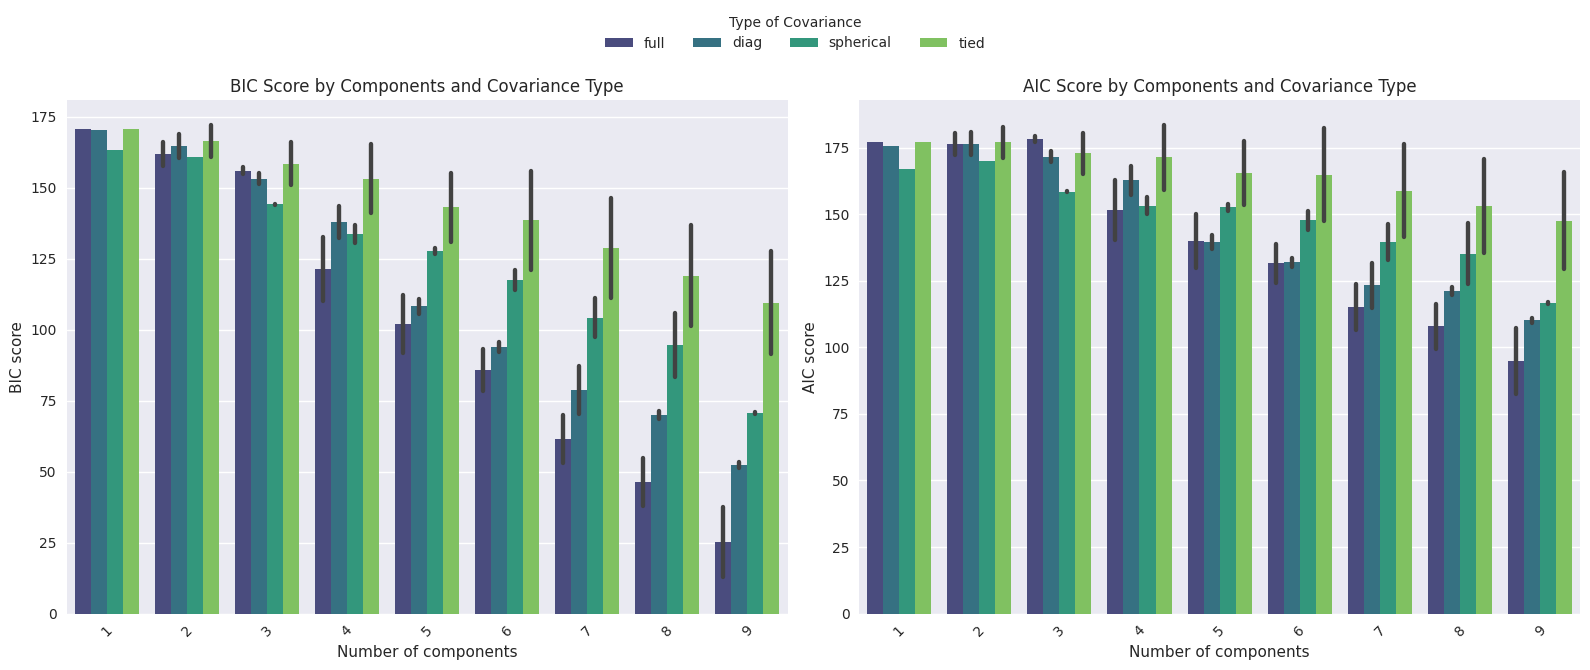

In [105]:
# 1. Crear la figura y dos subgráficos (1 fila, 2 columnas)
# IMPORTANTE: Al no usar 'sharey=True', cada gráfico tendrá su propia escala Y.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 2. Graficar BIC en el primer eje (ax1)
sns.barplot(
    data=search_mmg_bic_grid,
    x="Number of components",
    y="BIC score",
    hue="Type of covariance",
    ax=ax1,
    palette="viridis"
)
ax1.set_title("BIC Score by Components and Covariance Type")
ax1.tick_params(axis='x', rotation=45)

# 3. Graficar AIC en el segundo eje (ax2)
sns.barplot(
    data=search_mmg_aic_grid,
    x="Number of components",
    y="AIC score",
    hue="Type of covariance",
    ax=ax2,
    palette="viridis"
)
ax2.set_title("AIC Score by Components and Covariance Type")
# El eje Y del segundo gráfico NO se elimina, ya que tiene su propia escala.
ax2.tick_params(axis='x', rotation=45)

# 4. Manejar la leyenda compartida
# Obtener los handles y labels del primer gráfico
handles, labels = ax1.get_legend_handles_labels()

# Eliminar las leyendas individuales de los subgráficos
ax1.legend_.remove()
ax2.legend_.remove()

# Colocar la leyenda compartida en la figura
fig.legend(
    handles,
    labels,
    title="Type of Covariance",
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),
    ncol=len(labels)
)

# 5. Ajustar el layout y mostrar el gráfico
plt.tight_layout(rect=[0, 0.03, 1, 1.05])
plt.show()

In [101]:
best_mmg_bic = mmg_bic_grid_search.best_estimator_

In [91]:
labels = best_mmg_bic.predict(X)
bogota_mb_df.loc[:,'cluster'] = labels
display(bogota_mb_df.head(3))

,restaurante,direccion,descripcion,latitud,longitud,geometry,cluster
0,MAIKKI,Cra 75 # 24D – 48,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado, tocineta caramelizada en melao de maracuyá y panela de la hoya del rio Suárez, carne de res del Magdalena medio, queso fresco de pasta hilada, mayonesa de cilantro cimarrón del pacifico, cogollo de lechuga y pan artesanal. Un homenaje a lo nuestro. En pie de lucha por la comida rápida colombiana<br/><br/>Cra 75 # 24D – 48, Modelia<br/>Calle 119 # 11A – 24, Santa Bárbara<br/>Cra 47A # 98 – 47, Castellana</p>",4.668833,-74.116828,POINT (4.66883 -74.11683),8
1,MAIKKI,Calle 119 # 11A – 24,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado, tocineta caramelizada en melao de maracuyá y panela de la hoya del rio Suárez, carne de res del Magdalena medio, queso fresco de pasta hilada, mayonesa de cilantro cimarrón del pacifico, cogollo de lechuga y pan artesanal. Un homenaje a lo nuestro. En pie de lucha por la comida rápida colombiana<br/><br/>Cra 75 # 24D – 48, Modelia<br/>Calle 119 # 11A – 24, Santa Bárbara<br/>Cra 47A # 98 – 47, Castellana</p>",4.698395,-74.036585,POINT (4.69839 -74.03658),5
2,MAIKKI,Cra 47A # 98 – 47,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado, tocineta caramelizada en melao de maracuyá y panela de la hoya del rio Suárez, carne de res del Magdalena medio, queso fresco de pasta hilada, mayonesa de cilantro cimarrón del pacifico, cogollo de lechuga y pan artesanal. Un homenaje a lo nuestro. En pie de lucha por la comida rápida colombiana<br/><br/>Cra 75 # 24D – 48, Modelia<br/>Calle 119 # 11A – 24, Santa Bárbara<br/>Cra 47A # 98 – 47, Castellana</p>",4.686401,-74.060144,POINT (4.68640 -74.06014),0


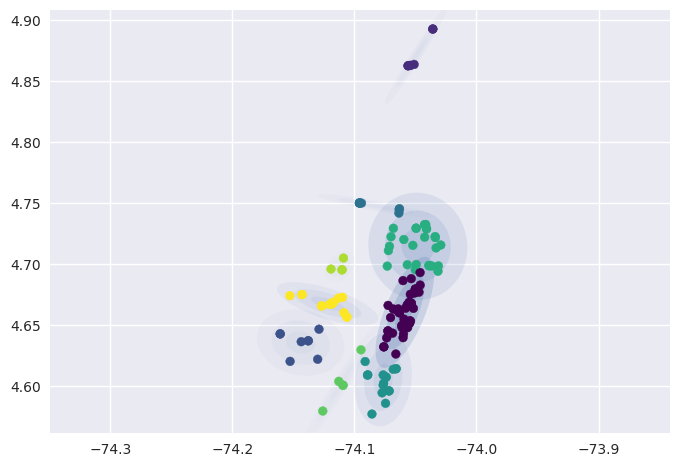

In [102]:
# Graficar
plot_gmm(best_mmg_bic, X)

(Utilice este espacio para describir el procedimiento, análisis, y conclusiones)

#### 3.1. Visualización de los resultados

Visualice las densidades estimadas por el  mejor modelo estimado en la sección anterior usando un mapa de calor interactivo, discuta los resultados.

In [112]:
# Utilice este espacio para escribir el código.

# --- 1. Función para calcular densidad GMM en grilla ---
def calcular_gmm_grid(modelo, datos, n_grid=150):
    """
    Calcula la densidad estimada por un modelo GMM en una grilla de puntos.

    Args:
        modelo (GaussianMixture): Modelo GMM entrenado.
        datos (np.ndarray): Array con coordenadas (lon, lat).
        n_grid (int): Resolución de la grilla.

    Returns:
        tuple: (pdf_grid, grid_lon, grid_lat)
    """
    lon_min, lat_min = datos.min(axis=0) - 0.01
    lon_max, lat_max = datos.max(axis=0) + 0.01
    grid_lon, grid_lat = np.mgrid[lon_min:lon_max:n_grid*1j, lat_min:lat_max:n_grid*1j]

    puntos = np.vstack([grid_lon.ravel(), grid_lat.ravel()]).T
    pdf = np.exp(modelo.score_samples(puntos))
    pdf_grid = pdf.reshape(grid_lon.shape)

    return pdf_grid, grid_lon, grid_lat


# --- 2. Crear GeoJSON de curvas de nivel ---
def crear_geojson_contorno(pdf_grid, grid_lon, grid_lat, color_mapa='Reds'):
    fig, ax = plt.subplots(figsize=(8, 8))
    contour_plot = ax.contourf(
        grid_lon, grid_lat, pdf_grid,
        levels=15, cmap=color_mapa, alpha=0.9
    )
    plt.close(fig)
    try:
        return geojsoncontour.contourf_to_geojson(
            contourf=contour_plot,
            ndigits=5
        )
    except Exception as e:
        print(f"Error en conversión directa: {e}")
        cmap = plt.get_cmap(color_mapa)
        base_color = to_rgba(cmap(0.5))
        hex_color = '#%02x%02x%02x' % tuple([int(255 * x) for x in base_color[:3]])
        return geojsoncontour.contourf_to_geojson(
            contourf=contour_plot,
            ndigits=5,
            geojson_properties={
                'stroke': hex_color,
                'fill': hex_color,
                'stroke-width': 1,
                'fill-opacity': 0.5
            }
        )


# --- 3. Añadir capa GeoJSON al mapa ---
def agregar_capas_a_mapa(mapa, geojson_data, nombre_capa, opacidad_fondo=0.3):
    if geojson_data:
        folium.GeoJson(
            json.loads(geojson_data),
            name=nombre_capa,
            style_function=lambda feature: {
                'fillColor': feature['properties'].get('fill', '#000000'),
                'fillOpacity': opacidad_fondo,
                'color': feature['properties'].get('stroke', '#000000'),
                'weight': feature['properties'].get('stroke-width', 2),
            }
        ).add_to(mapa)
        
    else:
        print(f"❌ No se pudo añadir la capa '{nombre_capa}'.")

In [117]:
# --- 4. Calcular densidades en la grilla ---
pdf_grid, grid_lon, grid_lat = calcular_gmm_grid(best_mmg_bic, X)

# --- 5. Crear GeoJSON de curvas ---
geojson_data = crear_geojson_contorno(pdf_grid, grid_lon, grid_lat, color_mapa="Blues")

# --- 6. Crear mapa base ---
map_mmg_bic = folium.Map(
    location = bogota_mb_location, 
    tiles="cartodb positron",
    # crs="EPSG:4326",
    zoom_start = 11
)

# --- 7. Añadir capa de densidad ---
agregar_capas_a_mapa(map_mmg_bic, geojson_data, "Curvas de densidad GMM", opacidad_fondo=0.5)

# --- 8.1 Algo de color ---
class ClusterColor(Enum):
    # Los 5 colores originales
    CLUSTER_0 = 'red'
    CLUSTER_1 = 'orange'
    CLUSTER_2 = 'green'
    CLUSTER_3 = 'purple'
    CLUSTER_4 = 'cadetblue'
    
    # Los 5 colores adicionales que combinan bien
    # Teoria del Color hecho con Gemini 2.5
    CLUSTER_5 = 'cyan'        # Complementario del rojo, vibrante
    CLUSTER_6 = 'blue'        # Complementario del naranja, clásico
    CLUSTER_7 = 'magenta'     # Fuerte contraste para el verde, moderno
    CLUSTER_8 = 'gold'        # Complementario del púrpura, regio
    CLUSTER_9 = 'coral'       # Cálido contraste para el cadetblue

# --- 8.2 Crear grupo de características para clusters para que queden encima ptos calientes ---
cluster_group = folium.FeatureGroup(name="Puntos de Restaurantes (GMM)")
cluster_group.add_to(map_mmg_bic)

# --- 8.3 Añadir puntos individuales ---
for _, record in bogota_mb_df.iterrows():
    color:str = ClusterColor[f'CLUSTER_{record.cluster}'].value
    popup:str = template.format(
        restaurante=record.restaurante,
        direccion=record.direccion,
        descripción=record.descripcion
    )
    folium.CircleMarker(
        [record.latitud, record.longitud],
        popup=folium.Popup(popup, max_width=256),
        tooltip=record.restaurante,
        radius=8,
        fill_color=color,
        fill=True,
        color=color,
        fill_opacity=0.1,
        weight=0
    ).add_to(cluster_group)

# --- 9. Control de capas ---
folium.LayerControl().add_to(map_mmg_bic)
map_mmg_bic

(Utilice este espacio para describir el procedimiento, análisis, y conclusiones)

### 4. Comparación con KDE

Estime ahora las densidades usando KDE bivariado de la librería `statsmodels` con el anchos de banda dado por `cv_ml`. Muestre los resultados usando un mapa interactivo. Compare los resultados obtenidos por el "mejor" modelo encontrado via MMG. 

In [ ]:
# Utilice este espacio para escribir el código.

(Utilice este espacio para describir el procedimiento, análisis, y conclusiones)